# CCGT+CCS NPV simulation

Run the CCGT+CCS electricity Monte Carlo simulation and visualize the resulting NPV distribution.

The summary also reports how many simulations have non-negative NPV (NPV >= 0) and how many have negative NPV.

In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

PROJECT_ROOT = Path.cwd()
while PROJECT_ROOT != PROJECT_ROOT.parent and not (PROJECT_ROOT / "src").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent

SRC_DIR = PROJECT_ROOT / "src"
if str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))

from electricity.electricity_npv_monte_carlo import (
    DEFAULT_RANDOM_SEED,
    DEFAULT_SAMPLE_SIZE,
    simulate_electricity_results,
)

from npv_summary import summarize_metric_signs


In [2]:
TECHNOLOGY = 'ccgt_ccs'
SAMPLE_SIZE = DEFAULT_SAMPLE_SIZE
RANDOM_SEED = DEFAULT_RANDOM_SEED

results_by_technology = simulate_electricity_results(
    sample_size=SAMPLE_SIZE,
    random_seed=RANDOM_SEED,
    technologies=(TECHNOLOGY,),
)
simulation = results_by_technology[TECHNOLOGY]
results = pd.DataFrame(simulation)
results.head()


,run_id,technology,annual_output_mwh,full_load_hours_per_year,lifetime_years,capacity_mw,capacity_kw,capex_eur_per_kw,fixed_opex_eur_per_kw_year,variable_opex_eur_per_mwh,...,initial_capex_eur,annual_revenue_eur,annual_fixed_opex_eur,annual_variable_opex_eur,annual_fuel_cost_eur,annual_emissions_cost_eur,annual_net_cash_flow_eur,npv_eur,discounted_lifetime_output_mwh,levelized_net_margin_eur_per_mwh
0,0,ccgt_ccs,1000000.0,4650.0,30.0,215.053763,215053.763441,2527.530862,44.379441,6.148274,...,5.435550e+08,94070000.0,9.543966e+06,6.148274e+06,1.159907e+08,2.347553e+06,-3.996052e+07,-9.934219e+08,1.125778e+07,-88.243114
1,1,ccgt_ccs,1000000.0,4650.0,30.0,215.053763,215053.763441,2553.204828,41.229368,5.417912,...,5.490763e+08,94070000.0,8.866531e+06,5.417912e+06,5.720997e+07,2.338193e+06,2.023739e+07,-3.212481e+08,1.125778e+07,-28.535646
2,2,ccgt_ccs,1000000.0,4650.0,30.0,215.053763,215053.763441,1639.691301,43.564899,6.038244,...,3.526218e+08,94070000.0,9.368796e+06,6.038244e+06,6.130297e+07,1.334901e+06,1.602509e+07,-1.722148e+08,1.125778e+07,-15.297397
3,3,ccgt_ccs,1000000.0,4650.0,30.0,215.053763,215053.763441,1494.032292,41.041380,7.037486,...,3.212973e+08,94070000.0,8.826103e+06,7.037486e+06,6.640827e+07,1.933551e+06,9.864592e+06,-2.102438e+08,1.125778e+07,-18.675419
4,4,ccgt_ccs,1000000.0,4650.0,30.0,215.053763,215053.763441,1820.200741,52.131530,6.780100,...,3.914410e+08,94070000.0,1.121108e+07,6.780100e+06,3.955699e+07,2.158276e+06,3.436355e+07,-4.583650e+06,1.125778e+07,-0.407154


In [3]:
npv_million_eur = results["npv_eur"] / 1_000_000
levelized_net_margin_eur_per_mwh = results["levelized_net_margin_eur_per_mwh"]
summary = pd.concat(
    [
        npv_million_eur.describe(percentiles=[0.05, 0.5, 0.95]).rename(
            "NPV million EUR"
        ),
        levelized_net_margin_eur_per_mwh.describe(percentiles=[0.05, 0.5, 0.95]).rename(
            "Levelized net margin EUR/MWh"
        ),
    ],
    axis=1,
)

npv_signs = summarize_metric_signs(npv_million_eur)
npv_sign_summary = pd.DataFrame(
    {
        "NPV category": ["Non-negative (NPV >= 0)", "Negative (NPV < 0)"],
        "Simulation count": [
            npv_signs["non_negative_count"],
            npv_signs["negative_count"],
        ],
        "Simulation share": [
            npv_signs["non_negative_share"],
            1.0 - npv_signs["non_negative_share"],
        ],
    }
)

display(summary)
display(npv_sign_summary)


,NPV million EUR,Levelized net margin EUR/MWh
count,100000.000000,100000.000000
mean,-424.473394,-37.704882
std,313.335407,27.832780
min,-1540.435262,-136.832911
5%,-990.919079,-88.020798
50%,-394.306528,-35.025237
95%,34.354091,3.051586
max,278.763770,24.761870


,NPV category,Simulation count,Simulation share
0,Non-negative (NPV >= 0),7229,0.07229
1,Negative (NPV < 0),92771,0.92771


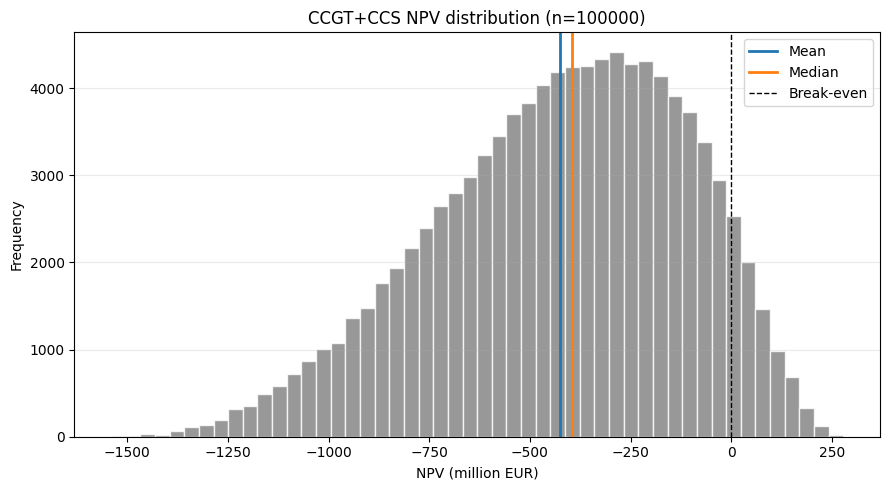

In [4]:
fig, ax = plt.subplots(figsize=(9, 5))

ax.hist(npv_million_eur, bins=50, color="tab:gray", edgecolor="white", alpha=0.8)
ax.axvline(npv_million_eur.mean(), color="tab:blue", linewidth=2, label="Mean")
ax.axvline(npv_million_eur.median(), color="tab:orange", linewidth=2, label="Median")
ax.axvline(0, color="black", linewidth=1, linestyle="--", label="Break-even")

ax.set_title(f"CCGT+CCS NPV distribution (n={SAMPLE_SIZE})")
ax.set_xlabel("NPV (million EUR)")
ax.set_ylabel("Frequency")
ax.grid(axis="y", alpha=0.25)
ax.legend()

fig.tight_layout()
plt.show()

## levelized net margin histogram


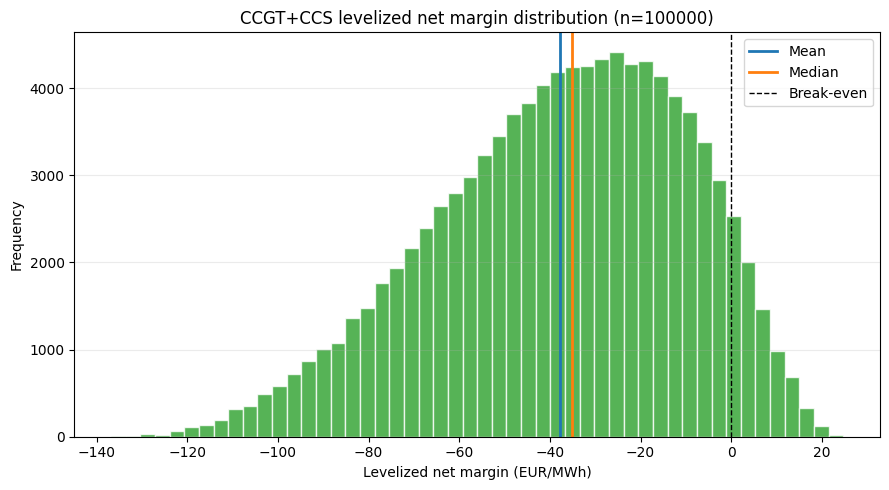

In [5]:
fig, ax = plt.subplots(figsize=(9, 5))

ax.hist(
    levelized_net_margin_eur_per_mwh,
    bins=50,
    color="tab:green",
    edgecolor="white",
    alpha=0.8,
)
ax.axvline(
    levelized_net_margin_eur_per_mwh.mean(),
    color="tab:blue",
    linewidth=2,
    label="Mean",
)
ax.axvline(
    levelized_net_margin_eur_per_mwh.median(),
    color="tab:orange",
    linewidth=2,
    label="Median",
)
ax.axvline(0, color="black", linewidth=1, linestyle="--", label="Break-even")

ax.set_title(f"CCGT+CCS levelized net margin distribution (n={SAMPLE_SIZE})")
ax.set_xlabel("Levelized net margin (EUR/MWh)")
ax.set_ylabel("Frequency")
ax.grid(axis="y", alpha=0.25)
ax.legend()

fig.tight_layout()
plt.show()


In [6]:
annual_components = results[
    [
        "annual_revenue_eur",
        "annual_fixed_opex_eur",
        "annual_variable_opex_eur",
        "annual_fuel_cost_eur",
        "annual_emissions_cost_eur",
        "annual_net_cash_flow_eur",
    ]
] / 1_000_000

annual_components.mean().rename("Mean annual value, million EUR")

annual_revenue_eur           94.070000
annual_fixed_opex_eur         9.620071
annual_variable_opex_eur      6.274325
annual_fuel_cost_eur         75.450280
annual_emissions_cost_eur     1.792008
annual_net_cash_flow_eur      0.933316
Name: Mean annual value, million EUR, dtype: float64